## imports

In [ ]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

## models

In [ ]:
#llm
##################

llm = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")
llm2 = init_chat_model("ollama:nemotron-3-super:cloud",base_url="https://ollama.com")


response = llm.invoke("What is the color of the sky answer in one word?")
print(response.content)

blue


## simple chatbot

In [ ]:
# simple chatbot with memory?
####################################
messages = [SystemMessage(content="You must answer every question with exactly one word.")]
while True:
    user_input = input("Enter your query?")
    if user_input.lower() == "exit":
        break
    else:
        print(f"User: {user_input}\n")
    messages.append(HumanMessage(content=user_input))
    response = llm.invoke(messages)  # acts as node
    print(f"Bot: {response.content}\n")
    messages.append(response)
    

User: remenber my name is manish negi

Bot: Noted

User: my fathers name is J.s

Bot: Recorded

User: whati is my name?

Bot: manishnegi



In [ ]:
messages

[SystemMessage(content='You must answer every question with exactly one word.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='remenber my name is manish negi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Noted', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T12:35:49.652569868Z', 'done': True, 'done_reason': 'stop', 'total_duration': 705220182, 'load_duration': None, 'prompt_eval_count': 37, 'prompt_eval_duration': None, 'eval_count': 70, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e92aa-3edc-7ba0-9743-ce1dea7a38f3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 70, 'total_tokens': 107}),
 HumanMessage(content='my fathers name is J.s', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Recorded', additional_kwargs={}, response_metadata={'model': 'nem

### chatbot with InMemoryChatMessageHistory

In [ ]:
sys_msz = SystemMessage(content="You must answer every question with exactly one word.")
history = InMemoryChatMessageHistory()
history.add_message(sys_msz)
llm = init_chat_model("google_genai:gemini-2.5-flash")

while True:
    user_input = input("User: Enter your query?")
    if user_input.strip().lower() == "exit":
        print("Bot: Thanks for chating!")
        break
    else:
        print(f"User:{user_input}\n")

    hum_msz = HumanMessage(content=user_input)
    history.add_message(hum_msz)

    response = llm.invoke(history.messages)
    print(f"Bot: {response.content}\n")
    history.add_message(response)

    


User:remember my name is manish negi

Bot: Okay

User:i am from Dehradun

Bot: Okay

Bot: Thanks for chating!


In [ ]:
history.messages

[SystemMessage(content='You must answer every question with exactly one word.', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='remember my name is manish negi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Okay', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eedef-1227-7d32-9413-5923512f5058-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 1, 'total_tokens': 20, 'input_token_details': {'cache_read': 0}}),
 HumanMessage(content='i am from Dehradun', additional_kwargs={}, response_metadata={}),
 AIMessage(content='Okay', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eedef-4763-7f70-896e-cb1aba88b5a0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata

## State

In [ ]:
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from langgraph.graph import MessagesState

class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]

class State(MessagesState):
    pass



## chatbot with graph

### 1st method

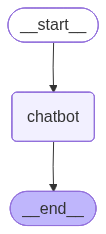

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from IPython.display import Image, display

class State(TypedDict):
    query: str
    response: str


def chatbot_node(state: State):
    messages = [
        SystemMessage(
            content="You must answer every question with exactly one word."
        ),
        HumanMessage(content=state["query"])
    ]

    # response = llm.invoke(messages)

    return {
        "response": response.content
    }


graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
response.content

'manishnegi'

In [ ]:
result = graph.invoke(
        {
            "query": "what is my name"
        }
    )

In [ ]:
result

{'query': 'what is my name', 'response': 'manishnegi'}

### 2nd method using MessageState

In [ ]:
from typing import Annotated
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict


class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]

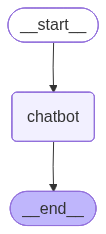

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import MessagesState
from langgraph.graph import START, END
from langchain_core.messages import SystemMessage


class State(MessagesState):
    pass


def chatbot_node(state: State):
    messages = [SystemMessage(content="You must answer every question with exactly one word.")] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}


graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:

user_input = "what comes after monday?"
result = graph.invoke({"messages": [HumanMessage(content=user_input)]})

In [ ]:
result

{'messages': [HumanMessage(content='what comes after monday?', additional_kwargs={}, response_metadata={}, id='beb7c54e-be73-4682-a506-64bdb75c612a'),
  AIMessage(content='Tuesday', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T13:00:58.667377275Z', 'done': True, 'done_reason': 'stop', 'total_duration': 442948972, 'load_duration': None, 'prompt_eval_count': 33, 'prompt_eval_duration': None, 'eval_count': 37, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e92c1-2405-7872-ac28-dbee03833574-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 33, 'output_tokens': 37, 'total_tokens': 70})]}

In [ ]:
print("Bot:",result["messages"][-1].content)

Bot: Tuesday


In [ ]:

user_input = "remenber my name is manish negi"
result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
print("Bot:",result["messages"][-1].content)

Bot: Acknowledged


### chatbot loop

In [ ]:
from langchain_core.messages import HumanMessage

conversation = []
while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        break
    print(f"you: {user_input}")

    result = graph.invoke({"messages": [HumanMessage(content=user_input)]})
    print("Bot:",result["messages"][-1].content)

you: can you Remember my name is manish negi
Bot: Yes
you: what is my name?
Bot: unknown


### chatbot with memory

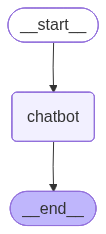

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import MessagesState
from langgraph.graph import START, END
from langchain_core.messages import SystemMessage


class State(MessagesState):
    pass


def chatbot_node(state: State):
    messages = [SystemMessage(content="You must answer every question with exactly one word.")] + state["messages"]
    response = llm.invoke(messages)
    return {"messages": [response]}


graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot_node)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

conversation = []
config = {
    "configurable": {
        "thread_id": "user-1"
    }
}

while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        break
    print(f"you: {user_input}")

    result = graph.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("Bot:",result["messages"][-1].content)

you: can you remember my name is manish negi
Bot: Yes
you: my fathers name is J.S
Bot: Yes
you: what is my name?
Bot: Manish Negi


In [ ]:
result

{'messages': [HumanMessage(content='can you remember my name is manish negi', additional_kwargs={}, response_metadata={}, id='3e92aaa0-9d4d-4c72-bfea-5e3a60938ac1'),
  AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T13:14:28.91129745Z', 'done': True, 'done_reason': 'stop', 'total_duration': 916978404, 'load_duration': None, 'prompt_eval_count': 37, 'prompt_eval_duration': None, 'eval_count': 162, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e92cd-a0c8-7753-8d64-80501882e5ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 162, 'total_tokens': 199}),
  HumanMessage(content='my fathers name is J.S', additional_kwargs={}, response_metadata={}, id='badf9b13-9ae4-4b38-bb7b-fe9ff19d3c9d'),
  AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud',

### state details

In [ ]:
state = graph.get_state(config)
state

StateSnapshot(values={'messages': [HumanMessage(content='can you remember my name is manish negi', additional_kwargs={}, response_metadata={}, id='3e92aaa0-9d4d-4c72-bfea-5e3a60938ac1'), AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T13:14:28.91129745Z', 'done': True, 'done_reason': 'stop', 'total_duration': 916978404, 'load_duration': None, 'prompt_eval_count': 37, 'prompt_eval_duration': None, 'eval_count': 162, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e92cd-a0c8-7753-8d64-80501882e5ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 162, 'total_tokens': 199}), HumanMessage(content='my fathers name is J.S', additional_kwargs={}, response_metadata={}, id='badf9b13-9ae4-4b38-bb7b-fe9ff19d3c9d'), AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-

### history in the graph

In [ ]:
all_states = [s for s in graph.get_state_history(config)]
all_states

[StateSnapshot(values={'messages': [HumanMessage(content='can you remember my name is manish negi', additional_kwargs={}, response_metadata={}, id='3e92aaa0-9d4d-4c72-bfea-5e3a60938ac1'), AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T13:14:28.91129745Z', 'done': True, 'done_reason': 'stop', 'total_duration': 916978404, 'load_duration': None, 'prompt_eval_count': 37, 'prompt_eval_duration': None, 'eval_count': 162, 'eval_duration': None, 'logprobs': None, 'model_name': 'nemotron-3-super:cloud', 'model_provider': 'ollama'}, id='lc_run--019e92cd-a0c8-7753-8d64-80501882e5ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 37, 'output_tokens': 162, 'total_tokens': 199}), HumanMessage(content='my fathers name is J.S', additional_kwargs={}, response_metadata={}, id='badf9b13-9ae4-4b38-bb7b-fe9ff19d3c9d'), AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron

In [ ]:
to_replay = all_states[-2]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='can you remember my name is manish negi', additional_kwargs={}, response_metadata={}, id='3e92aaa0-9d4d-4c72-bfea-5e3a60938ac1')]}, next=('chatbot',), config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f160189-3d92-6b2c-8000-6a24de522e51'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-04T13:23:30.116074+00:00', parent_config={'configurable': {'thread_id': 'user-1', 'checkpoint_ns': '', 'checkpoint_id': '1f160189-3c7f-6877-bfff-d1bb668be420'}}, tasks=(PregelTask(id='fa9f6cb2-b25b-01d9-a7b8-0912dd1ca66f', name='chatbot', path=('__pregel_pull', 'chatbot'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='Yes', additional_kwargs={}, response_metadata={'model': 'nemotron-3-super:cloud', 'created_at': '2026-06-04T13:14:28.91129745Z', 'done': True, 'done_reason': 'stop', 'total_duration': 916978404, 'load_duration': None, 'prompt_eval_count

In [ ]:
to_replay.values

{'messages': [HumanMessage(content='can you remember my name is manish negi', additional_kwargs={}, response_metadata={}, id='3e92aaa0-9d4d-4c72-bfea-5e3a60938ac1')]}

In [ ]:
to_replay.next

('chatbot',)

In [ ]:
to_replay.config

{'configurable': {'thread_id': 'user-1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f160189-3d92-6b2c-8000-6a24de522e51'}}

## tool in chat bot

### tool based agent example 1

In [ ]:
from langchain_core.tools import tool

# @tool
# def write_email(to: str, subject: str, content: str) -> str:
#     """Write and send an email."""
#     # Placeholder response - in real app would send email
#     return f"Email sent to {to} with subject '{subject}' and content: {content}"



import os

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write an email and save a copy to a local log file."""
    log_file = "sent_emails.txt"
    
    # Format the email data for clean visual separation in the file
    email_entry = (
        f"=== NEW EMAIL ===\n"
        f"To: {to}\n"
        f"Subject: {subject}\n"
        f"Content:\n{content}\n"
        f"=================\n\n"
    )
    
    # Append the email data to the local file
    with open(log_file, "a", encoding="utf-8") as file:
        file.write(email_entry)
        
    return f"Email successfully saved locally to {log_file} and marked as sent to {to}."


tools = [write_email]
llm = init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

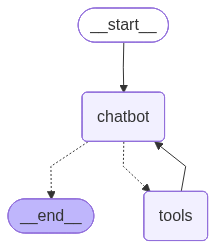

In [ ]:
from langgraph.graph import StateGraph
from langgraph.graph import MessagesState
from langgraph.graph import START, END
from langchain_core.messages import SystemMessage
from langgraph.prebuilt import ToolNode

class State(MessagesState):
    pass


def chatbot_node(state: State):
    messages = [SystemMessage(content="You are a helpful assistant. Use tools whenever required.")] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def route_tools(state):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"

    return "__end__"

tool_node = ToolNode(tools)



builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", tool_node)
builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {
        "tools": "tools",
        "__end__": END
    }
)

builder.add_edge("tools", "chatbot")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
user_input = "Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM"
config = {
    "configurable": {
        "thread_id": "user-2"
    }
}

result = graph.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
print("Bot:",result["messages"][-1].content)

Bot: I have sent the email to john@gmail.com with the subject "Meeting" and the content "We will meet tomorrow at 10 AM".


In [ ]:
result

{'messages': [HumanMessage(content='Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM', additional_kwargs={}, response_metadata={}, id='4dc43127-2691-4479-af37-60341ce125b8'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'write_email', 'arguments': '{"to": "john@gmail.com", "content": "We will meet tomorrow at 10 AM", "subject": "Meeting"}'}, '__gemini_function_call_thought_signatures__': {'5bb7ef61-4759-4f9f-825e-396e47e6b48d': 'Cq0CAQw51sfrslk1TRwHWH2a1LRf9xjTJfQNQOiSi4YWGUNdwxrpzFiNielfzNtKOGyAFXOqgN1rei9vEf/TAhDjN1YIFoaEX2c6uJbmgB4WJB/eQDeUsMUKaHKDj7CLsvRYeqzcwzfNeH4KIhrqcvj6aN9Dg3inqOQtWLbO/m79pz6ncgr75NtlKYbcIF4Ymn45TtTGQJDofdRahHl7s33meSvfFjrkZ6lP/amez9A/QPZxZvDXMHRb0UjtjQJAgk8AB3pyB5NcyLBEj94AODr8VVBK2+aEWU6GVtkr9RS7zmoi+RlscwVRtiV/Ctv9F6Vv1LJ5crzhBgKrqvXbvmKD0pp0eE4GhLug1+deMXdKWnp7jjd/XZP1lSMR8or6ktW0Z2nkzp7SA5JX+vcu6g=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safe

In [ ]:
for msg in result["messages"]:
    print(type(msg).__name__, "->", msg.content)

HumanMessage -> Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM
AIMessage -> 
ToolMessage -> Email sent to john@gmail.com with subject 'Meeting' and content: We will meet tomorrow at 10 AM
AIMessage -> I have sent the email to john@gmail.com with the subject "Meeting" and the content "We will meet tomorrow at 10 AM".


In [ ]:
from langchain_core.messages import HumanMessage

conversation = []
config = {
    "configurable": {
        "thread_id": "user-2"
    }
}

while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        break
    print(f"you: {user_input}")

    result = graph.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print("Bot:",result["messages"][-1].content)

In [ ]:
user_input = "Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM"

### graph based router

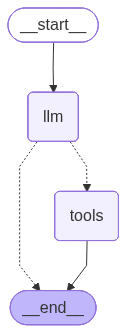

In [ ]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", END)
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

--- Calling LLM ---
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (509f045a-a8c7-4afe-ace4-b8f6e5351f33)
 Call ID: 509f045a-a8c7-4afe-ace4-b8f6e5351f33
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [ ]:
messages

{'messages': [HumanMessage(content='Hello, what is 2 multiplied by 2?', additional_kwargs={}, response_metadata={}, id='8f10d33a-5cca-4362-a686-8ddea812be51'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=

### graph agent with tool

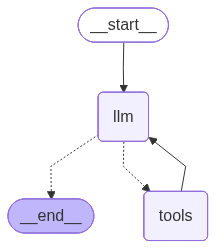

In [ ]:

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import HumanMessage
from IPython.display import Image
## tool definiton
#----------------------

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(MessagesState)
builder.add_node("llm", call_llm)
builder.add_node(
    "tools",
    ToolNode([multiply])
)

builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    tools_condition
)
builder.add_edge("tools", "llm")
graph = builder.compile()


# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2?")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

--- Calling LLM ---
--- Calling LLM ---
================================ Human Message =================================

Hello, what is 2 multiplied by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (289910c2-c1a9-4583-a296-f498a5cc2322)
 Call ID: 289910c2-c1a9-4583-a296-f498a5cc2322
  Args:
    b: 2
    a: 2
================================= Tool Message =================================
Name: multiply

4
================================== Ai Message ==================================

2 multiplied by 2 is 4.


### graph agent with custom tool node and conditional edge

In [ ]:
from langgraph.graph import END
from langchain_core.messages import ToolMessage

def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

llm_with_tools = llmg.bind_tools([multiply])


def call_llm(state: MessagesState):
    print("--- Calling LLM ---")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



def my_tools_condition(state):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END


tool_map = {"multiply": multiply}

def custom_tool_node(state):
    print("--- Executing Tools ---")
    last_message = state["messages"][-1]
    tool_messages = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_func = tool_map[tool_name]
        result = tool_func(**tool_args)
        tool_messages.append(
            ToolMessage(
                content=str(result),
                tool_call_id=tool_call["id"]
            )
        )
    return {
        "messages": tool_messages
    }


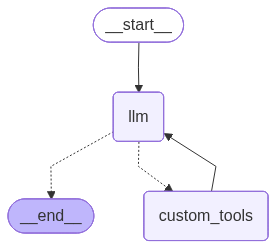

In [ ]:


builder = StateGraph(MessagesState)

builder.add_node("llm", call_llm)
builder.add_node("custom_tools", custom_tool_node)
builder.add_edge(START, "llm")
builder.add_conditional_edges(
    "llm",
    my_tools_condition,
    {
        "custom_tools": "custom_tools",
        END: END
    }
)

builder.add_edge("custom_tools", "llm")

graph = builder.compile()
# View
display(Image(graph.get_graph().draw_mermaid_png()))

### inside custom tool function execution

In [ ]:
state = {'messages': [HumanMessage(content='Hello, what is 2 multiplied by 2?', additional_kwargs={}, response_metadata={}, id='8f10d33a-5cca-4362-a686-8ddea812be51'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 84, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 66}}),
  ToolMessage(content='4', name='multiply', id='0ead0a83-348c-47aa-8862-15119aa0ee11', tool_call_id='509f045a-a8c7-4afe-ace4-b8f6e5351f33')]}

In [ ]:
state['messages'][-2]

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [ ]:
tool_map = {"multiply": multiply}

print("--- Executing Tools ---")
last_message = state["messages"][-2]
tool_messages = []
for tool_call in last_message.tool_calls:
    tool_name = tool_call["name"]
    tool_args = tool_call["args"]
    tool_func = tool_map[tool_name]
    result = tool_func(**tool_args)
    tool_messages.append(
        ToolMessage(
            content=str(result),
            tool_call_id=tool_call["id"]
        )
    )
rs = {
    "messages": tool_messages
}

--- Executing Tools ---


In [ ]:
last_message

AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 2, "b": 2}'}, '__gemini_function_call_thought_signatures__': {'509f045a-a8c7-4afe-ace4-b8f6e5351f33': 'CsACAQw51sffDh0d0tXE3jgIda87TLRNIzqGWtGg9BafGJ2z1w4LA0Tsjv7Eu88JPyqwit0huHFlA6HKKf71bZdyhmB0dUgDM2FIu9Htq9wlh/ZXvyKcE2pQEi60nLOXbFNlIqy25cLIASp+pRAqSJYeXNTSzDZ+51emfltKrPphh/WJMeBcaT39YguaK5V2UCytA+Xghgc03ieNzvsUt+qnQWoBP84MQc6bN8fUHJVZ0G46ZIFvQToGCnxt6JeemIY/UcVwTyMveuPyBjkGJnqW3xz/4SaRfGhb40NWfpQqQmA3IEioD0jVacCKUfmVfMqRwT/JCW8KPwMtsnuh/WZ7puwlbRfoiGLZyjp6Af09qHcnIaefZu2wZNW3VbRocH0B/JpCKzPKFPqGn9EV/MphYUxf6htISnq79dISSqoc7gk='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f0275-a743-7411-a91e-7b4802c3b868-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input

In [ ]:
last_message.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 2},
  'id': '509f045a-a8c7-4afe-ace4-b8f6e5351f33',
  'type': 'tool_call'}]

In [ ]:
tool_name = tool_call["name"]
tool_args = tool_call["args"]
tool_func = tool_map[tool_name]

In [ ]:
tool_func

<function __main__.multiply(a: int, b: int) -> int>

In [ ]:
tool_map

{'multiply': <function __main__.multiply(a: int, b: int) -> int>}

In [ ]:
tool_messages

[ToolMessage(content='4', tool_call_id='509f045a-a8c7-4afe-ace4-b8f6e5351f33')]

## human in the loop 

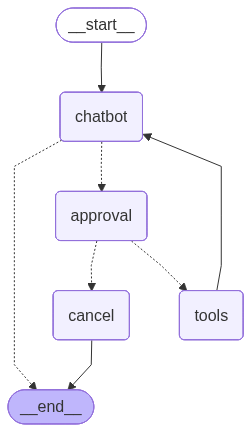

In [ ]:
from typing import Annotated

# from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    AIMessage,
)

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END,
)
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command



class State(MessagesState):
    approved: bool

def approval_node(state):
    last_ai_message = state["messages"][-1]
    tool_call = last_ai_message.tool_calls[0]
    approval = interrupt(
        {
            "question": "Do you approve sending this email?",
            "tool_name": tool_call["name"],
            "tool_args": tool_call["args"]
        }
    )
    return {
        "approved": approval
    }


def route_after_approval(state):
    if state["approved"]:
        return "tools"

    return "cancel"

def cancel_node(state):
    return {"messages": [AIMessage(content="Email sending cancelled.")]}


def chatbot_node(state: State):
    messages = [SystemMessage(content="You are a helpful assistant. Use tools whenever required.")] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def route_tools(state):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "approval"

    return "__end__"


# def route_tools(state):
#     last_message = state["messages"][-1]

#     if hasattr(last_message, "tool_calls") and last_message.tool_calls:
#         return "tools"

#     return "__end__"

tool_node = ToolNode(tools)




builder = StateGraph(State)

builder.add_node("chatbot", chatbot_node)
builder.add_node("tools", tool_node)
builder.add_node("approval", approval_node)
builder.add_node("cancel", cancel_node)


builder.add_edge(START, "chatbot")

builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {
        "approval": "approval",
        "__end__": END,
    },
)

builder.add_conditional_edges(
    "approval",
    route_after_approval,
    {
        "tools": "tools",
        "cancel": "cancel"
    }
)




builder.add_edge("tools", "chatbot")
builder.add_edge("cancel", END)



memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
user_input = "Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM"

result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config,
    )


In [ ]:
result

{'messages': [HumanMessage(content='Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM', additional_kwargs={}, response_metadata={}, id='090058b5-69cd-4db1-9a1f-557241ce00c7'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'write_email', 'arguments': '{"to": "john@gmail.com", "content": "We will meet tomorrow at 10 AM", "subject": "Meeting"}'}, '__gemini_function_call_thought_signatures__': {'a10f603c-4259-4412-83e8-3dd97811307c': 'CoUGAQw51sfjYoTzSBdCMf4qZfp1sgqIx31OhFDqS53vTA4YS0i3XzevRNhWd60Vb22/1Ebq6ABiZW+Q8afXrSJGMLVxRTxBbcu/FyVktiCibOX678+W6C2F2m6SzyX+VuRgKsbZ1jh37FpGyaWMZw6v9v1JUjFkt/fa4sDvOA+ScmNxwR+7EzechtK2O0QUUaPXrIbfGyLys2Ax0FFrm//mGMF4P9M0tpGWJhQFhlGJLrbR0726IK0kapOV3THy0SSZVHjy15PtDm+Iodidp2k7YIHGdyyRpq0/c86EzAW2o7YB5dNHKO6Nn1pJMs0I+rSp8+IBNYwR1bEvQ2mkDhcE+stfMngHokWRbWZxVCNXPqhRkuqEbqhHaXAl3XWrjsLa3RQCCs2+rLLNdANEbYFtEyXAEcnLf3z68cysBHPHEF2ldJrbEYQvF4a/u6bGuiqVJ+nRQkVRNxelyphIWjz83X6QyKiPYRlzr4faRtU1c9FZ

In [ ]:
if "__interrupt__" in result:

    interrupt_data = result["__interrupt__"][0].value

    print("\nApproval Required")
    print("-" * 40)
    print(interrupt_data)
    print("-" * 40)


Approval Required
----------------------------------------
{'question': 'Do you approve sending this email?', 'tool_name': 'write_email', 'tool_args': {'to': 'john@gmail.com', 'content': 'We will meet tomorrow at 10 AM', 'subject': 'Meeting'}}
----------------------------------------


In [ ]:
interrupt_data

{'question': 'Do you approve sending this email?',
 'tool_name': 'write_email',
 'tool_args': {'to': 'john@gmail.com',
  'content': 'We will meet tomorrow at 10 AM',
  'subject': 'Meeting'}}

In [ ]:
from langgraph.types import interrupt, Command

answer = "yes"

result = graph.invoke(
            Command(
                resume=answer.lower() == "yes"
            ),
            config=config,
        )

In [ ]:
result

{'messages': [HumanMessage(content='Send an email to john@gmail.com with subject Meeting and content We will meet tomorrow at 10 AM', additional_kwargs={}, response_metadata={}, id='090058b5-69cd-4db1-9a1f-557241ce00c7'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'write_email', 'arguments': '{"to": "john@gmail.com", "content": "We will meet tomorrow at 10 AM", "subject": "Meeting"}'}, '__gemini_function_call_thought_signatures__': {'a10f603c-4259-4412-83e8-3dd97811307c': 'CoUGAQw51sfjYoTzSBdCMf4qZfp1sgqIx31OhFDqS53vTA4YS0i3XzevRNhWd60Vb22/1Ebq6ABiZW+Q8afXrSJGMLVxRTxBbcu/FyVktiCibOX678+W6C2F2m6SzyX+VuRgKsbZ1jh37FpGyaWMZw6v9v1JUjFkt/fa4sDvOA+ScmNxwR+7EzechtK2O0QUUaPXrIbfGyLys2Ax0FFrm//mGMF4P9M0tpGWJhQFhlGJLrbR0726IK0kapOV3THy0SSZVHjy15PtDm+Iodidp2k7YIHGdyyRpq0/c86EzAW2o7YB5dNHKO6Nn1pJMs0I+rSp8+IBNYwR1bEvQ2mkDhcE+stfMngHokWRbWZxVCNXPqhRkuqEbqhHaXAl3XWrjsLa3RQCCs2+rLLNdANEbYFtEyXAEcnLf3z68cysBHPHEF2ldJrbEYQvF4a/u6bGuiqVJ+nRQkVRNxelyphIWjz83X6QyKiPYRlzr4faRtU1c9FZ

In [ ]:
print(
    "\nBot:",
    result["messages"][-1].content
)


Bot: Email sent successfully!


## chat loop with human feedback

### human feedback with invoke()

In [ ]:
# =====================================================
# CONFIG
# =====================================================

config = {
    "configurable": {
        "thread_id": "user-1"
    }
}


# =====================================================
# CHAT LOOP
# =====================================================

while True:

    user_input = input("\nYou: ")

    if user_input.lower() == "exit":
        break
    
    print(f"You: {user_input}")
    result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config,
    )

    # -------------------------------------
    # INTERRUPT HANDLING
    # -------------------------------------

    if "__interrupt__" in result:

        interrupt_data = result["__interrupt__"][0].value

        print("\nApproval Required")
        print("-" * 40)
        print(interrupt_data)
        print("-" * 40)

        answer = input(
            "\nApprove sending email? (yes/no): "
        )

        result = graph.invoke(
            Command(
                resume=answer.lower() == "yes"
            ),
            config=config,
        )

    # -------------------------------------
    # FINAL RESPONSE
    # -------------------------------------

    print(
        "\nBot:",
        result["messages"][-1].content
    )

You: hey can you send mail to smriti@gmail.com that I want to have call with here tommorow at 4 pm urgently to discuss about project.

Approval Required
----------------------------------------
{'question': 'Do you approve sending this email?', 'tool_name': 'write_email', 'tool_args': {'subject': 'Urgent: Project Discussion Tomorrow at 4 PM', 'to': 'smriti@gmail.com', 'content': 'Hi Smriti, I would like to have an urgent call with you tomorrow at 4 PM to discuss the project. Please let me know if this time works for you.'}}
----------------------------------------

Bot: Sure, I have sent an email to smriti@gmail.com with the subject "Urgent: Project Discussion Tomorrow at 4 PM" and content "Hi Smriti, I would like to have an urgent call with you tomorrow at 4 PM to discuss the project. Please let me know if this time works for you."


In [ ]:
# =====================================================
# CONFIG
# =====================================================

config = {
    "configurable": {
        "thread_id": "user-1"
    }
}


# =====================================================
# CHAT LOOP
# =====================================================

while True:

    user_input = input("\nYou: ")

    if user_input.lower() == "exit":
        break
    
    print(f"You: {user_input}")
    result = graph.invoke(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config,
    )

    # -------------------------------------
    # INTERRUPT HANDLING
    # -------------------------------------

    if "__interrupt__" in result:

        interrupt_data = result["__interrupt__"][0].value

        print("\nApproval Required")
        print("-" * 40)
        print(interrupt_data)
        print("-" * 40)

        answer = input(
            "\nApprove sending email? (yes/no): "
        )

        result = graph.invoke(
            Command(
                resume=answer.lower() == "yes"
            ),
            config=config,
        )

    # -------------------------------------
    # FINAL RESPONSE
    # -------------------------------------

    print(
        "\nBot:",
        result["messages"][-1].content
    )

You: can you tell me whom i have shared last mail

Bot: [{'type': 'text', 'text': 'You have shared the last mail with smriti@gmail.com.', 'extras': {'signature': 'CpkCAQw51sf7L/Ldz4cDMFAjxIYgVXsAwnB5kbte0mqi6RgMPEg5iPFOvzpAPxdLL86fMuAR+4bM1ZJsR8dJXBG5CR07ZQ812SlL3+6fwH8T6UtXG2xL6n26ubViDH7C9sbdnrwjQltiaNg1EqFyodV1sZr0hErqpZYFVj4e/ndIZ3SSg+gr5d/UEBbmzUqC7DHPFzzfkUw0F+xM5nRrScO9Tspo76GEK5Ei9hacb8zBxgZwJ2xED9l1GAAcn8ysGssgLiI9iwOCwZTy2oVbCRd2owdesQ9HlIB+clQSev3ZtnRiLVaObMHz1BNFCNr4pBaGkjoG2WoKZPWbNNCmWIr4WPBuexV1uKG8VIQbweEgGyR+z5iPN8rMCT0='}}]


### human feedback with stream()

In [ ]:
from langgraph.types import Command

while True:

    user_input = input("\nYou: ")

    if user_input.lower() == "exit":
        break

    interrupted = False

    for event in graph.stream(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config
    ):

        print("\nEVENT:")
        print(event)

        if "__interrupt__" in event:

            interrupted = True

            interrupt_data = event["__interrupt__"][0].value

            print("\nApproval Required")
            print(interrupt_data)

    if interrupted:

        answer = input(
            "\nApprove sending email? (yes/no): "
        )

        for event in graph.stream(
            Command(
                resume=answer.lower() == "yes"
            ),
            config=config
        ):

            print("\nEVENT:")
            print(event)

### stream with values

In [ ]:
from langgraph.types import Command

while True:

    user_input = input("\nYou: ")

    if user_input.lower() == "exit":
        break

    interrupted = False

    for event in graph.stream(
        {
            "messages": [
                HumanMessage(content=user_input)
            ]
        },
        config=config
    ):

        print("\nEVENT:")
        print(event)

        if "__interrupt__" in event:

            interrupted = True

            interrupt_data = event["__interrupt__"][0].value

            print("\nApproval Required")
            print(interrupt_data)

    if interrupted:

        answer = input(
            "\nApprove sending email? (yes/no): "
        )

        for event in graph.stream(
            Command(
                resume=answer.lower() == "yes"
            ),
            config=config
        ):

            print("\nEVENT:")
            print(event)